In [16]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from tabulate import tabulate
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score

#import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords

Chargement des données

In [58]:
#movies = pd.read_csv('ratings_preprocessed.csv')
#tagsMovie = pd.read_csv('tags_preprocessed.csv')
#genomeMovie = pd.read_csv('genome_scores_preprocessed.csv')

tagsMovie = pd.read_csv('tags_cleaned.csv')
genomeMovie = pd.read_csv('genome_tags_movies.csv')

	
Filtrage basé sur le contenu : on utilise l'information qu'on connaît sur les intérêts des utilisateurs comme liaison pour les recommandations potentielles. Ces intérêts sont dans le dataframe tagsMovie

************  
**MODELE 1** : on utilise les tags des utilisateurs, et on détermine les films similaires  
************  

In [18]:
# nous avons une ligne par film. Et pour chaque film nous avons l'ensemble des tags des utilisateurs en un mot
tagsMovie.head(2)

,movieId,tag,title
0,1,Watched computer animation Disney animated fea...,Toy Story (1995)
1,2,time travel adapted from:book board game child...,Jumanji (1995)


In [ ]:
# tokenization et vectorisation des tags
# création d'un TfidfVectorizer et suppression des mots vides
tfidf = TfidfVectorizer(stop_words='english')
# Adapter et transformer les données en une matrice tfidf
matrice_tfidf = tfidf.fit_transform(tagsMovie['tag'])
print(matrice_tfidf.shape)
# on a 19545 films et 23863 mots importants après avoir enlevé les mots vides

# similarité des films
# On calcule la similarité cosinus
sim_cosinus = cosine_similarity(matrice_tfidf, matrice_tfidf)

# On calcule la similarité euclidienne
# On rappelle que dans la mesure euclidienne plus la distance est courte, plus la similitude est élevée. Pour garantir que des valeurs plus élevées correspondent à une plus grande similarité (convention courante dans les systèmes de recommandation) on fait la transformation
sim_euclidienne = 1 / (1 + euclidean_distances(matrice_tfidf))

# sim_cosinus et sim_euclidienne sont de simples tableaux numpy dont la position des films correspond à la position dans tagsMovie

(19545, 23863)


In [50]:
# indices indexés par movieId (unique)
# indices.values (les valeurs de la Series) = les positions (0, 1, 2, 3...)
# indices.index (l'index de la Series) = les movieId
indices = pd.Series(range(0, len(tagsMovie)), index=tagsMovie['movieId'])

# Fonction de recommandation basée sur la similarité cosinus (ou euclidienne)
def recommander_films(movie_id, mat_sim=sim_cosinus, num_recommendations=10):

    # Vérifier que le movieId existe
    if movie_id not in indices.index:
        print(f"Aucun film trouvé pour movieId={movie_id}")
        return None
    
    # Récupérer la position dans la matrice
    idx = indices[movie_id]
    titre_film = tagsMovie.iloc[idx]['title']

    print(f"Films recommandés pour : {titre_film} \n")

    # Obtenir et trier les scores de similarité
    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )

    # Top N films similaires (hors le film lui-même)
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(tagsMovie.iloc[i]['title'], score) for i, score in top_similair]

    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

In [62]:
# recherche d'un exemple de titre à tester
#exple_titre = 'Titanic (1997)'
#exple_titre = 'Matrix, The (1999)'
#exple_titre = 'Superman (1978)'
#exple_titre = 'Batman: The Dark Knight Returns, Part 1 (2012)'
#exple_titre = 'Aladdin (1992)'
tagsMovie.loc[tagsMovie['title'].str.contains("Matrix", case=False, na=False), ['movieId', 'title']]

,movieId,title
2117,2571,"Matrix, The (1999)"
5393,6365,"Matrix Reloaded, The (2003)"
5882,6934,"Matrix Revolutions, The (2003)"
8115,27660,"Animatrix, The (2003)"


In [63]:
movie_id = 2571
print("Similarité cosinus")
print(recommander_films(movie_id, sim_cosinus))
print("Similarité euclidienne")
print(recommander_films(movie_id, sim_euclidienne))

Similarité cosinus
Films recommandés pour : Matrix, The (1999) 

+--------------------------------+---------------------+
|             Titre              | Score de similarité |
+--------------------------------+---------------------+
| Matrix Revolutions, The (2003) | 0.8382654276255842  |
|  Matrix Reloaded, The (2003)   | 0.8178931120517118  |
|         Avalon (2001)          | 0.6590175732412529  |
|          Tron (1982)           | 0.6061812105369216  |
|      Strange Days (1995)       | 0.5705648266305285  |
|        eXistenZ (1999)         | 0.5537087660358879  |
|        Dark City (1998)        | 0.5303637920761914  |
|  Thirteenth Floor, The (1999)  | 0.5174100385817608  |
|          Gamer (2009)          | 0.48892095590733786 |
|      Tron: Legacy (2010)       | 0.4788438846213045  |
+--------------------------------+---------------------+
Similarité euclidienne
Films recommandés pour : Matrix, The (1999) 

+--------------------------------------------+---------------------+

************  
**MODELE 2** : on utilise les genome tags, et on détermine les films similaires  
************  

In [59]:
print(f"Films couverts par genome  : {len(genomeMovie)}")
display(genomeMovie.head(2))

Films couverts par genome  : 10381


,movieId,tag,title
0,1,3d action adventure affectionate animal movie ...,Toy Story (1995)
1,2,action adapted from:book adventure animal movi...,Jumanji (1995)


In [65]:
# Vectorisation TF-IDF sur les tags genome
tfidf_genome = TfidfVectorizer(stop_words='english')
matrice_tfidf_genome = tfidf_genome.fit_transform(genomeMovie['tag'])
print(f"Matrice genome : {matrice_tfidf_genome.shape}  "
      f"({matrice_tfidf_genome.shape[0]} films × {matrice_tfidf_genome.shape[1]} tokens)")

# Similarité cosinus
sim_cosinus_genome = cosine_similarity(matrice_tfidf_genome, matrice_tfidf_genome)

# Similarité euclidienne (inversée pour que plus grand = plus similaire)
sim_euclidienne_genome = 1 / (1 + euclidean_distances(matrice_tfidf_genome))

Matrice genome : (10381, 1124)  (10381 films × 1124 tokens)


In [66]:
# Index par movieId (unique)
indices_genome = pd.Series(range(len(genomeMovie)), index=genomeMovie['movieId'])

def recommander_films_genome(movie_id, mat_sim=sim_cosinus_genome, num_recommendations=10):
    # Vérifier que le movieId existe
    if movie_id not in indices_genome.index:
        print(f"Aucun film trouvé pour movieId={movie_id}")
        return None

    # Récupérer la position dans la matrice de similarité
    idx = indices_genome[movie_id]
    titre_film = genomeMovie.iloc[idx]['title']

    print(f"Films recommandés pour : {titre_film} (movieId={movie_id})\n")

    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )

    # Top N films similaires (hors le film lui-même)
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(genomeMovie.iloc[i]['title'], score) for i, score in top_similair]
    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

#display(indices_genome.head(2))

In [68]:
movie_id = 2571
print("Similarité cosinus")
print(recommander_films_genome(movie_id, sim_cosinus_genome))
print("Similarité euclidienne")
print(recommander_films_genome(movie_id, sim_euclidienne_genome))

Similarité cosinus
Films recommandés pour : Matrix, The (1999) (movieId=2571)

+-------------------------------------------------------+---------------------+
|                         Titre                         | Score de similarité |
+-------------------------------------------------------+---------------------+
|              Matrix Reloaded, The (2003)              | 0.7034947223455797  |
|                Terminator, The (1984)                 | 0.6977642843541312  |
|       Star Wars: Episode IV - A New Hope (1977)       | 0.6813428598817732  |
|           Terminator 2: Judgment Day (1991)           |  0.680601098175743  |
|                Minority Report (2002)                 | 0.6672545311665922  |
| Star Wars: Episode V - The Empire Strikes Back (1980) | 0.6647115008479465  |
|   Star Wars: Episode VI - Return of the Jedi (1983)   | 0.6621017913226102  |
|            Matrix Revolutions, The (2003)             |  0.646167338630008  |
|                     Aliens (1986)      

************  
**Modèle 3** : clustering sur la base des tags utilisateurs  
************  

In [70]:
# créons un dataframe qui contient les tags utilisateurs, en mettant movieId comme index
mv = tagsMovie.set_index('movieId')
mv = mv[['tag']]

stop_words = set(stopwords.words('english'))

# suppression des mots vides dans les tags pour le traitement du texte
def preprocess(text):
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

mv['tags_clean'] = mv['tag'].apply(preprocess)
display(mv.head())
tfidf_cl = TfidfVectorizer()
tfidf_matrix_cl = tfidf_cl.fit_transform(mv['tags_clean'])

,tag,tags_clean
movieId,,
1,Watched computer animation Disney animated fea...,watched computer animation disney animated fea...
2,time travel adapted from:book board game child...,time travel adapted from:book board game child...
3,old people that is actually funny sequel fever...,old people actually funny sequel fever grun ru...
4,chick flick revenge characters chick flick cha...,chick flick revenge characters chick flick cha...
5,Diane Keaton family sequel Steve Martin weddin...,diane keaton family sequel steve martin weddin...


In [ ]:
# recherche du k optimal pour le clustering KMeans
range_n_clusters = range(5, 500, 5)
distortions = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tfidf_matrix_cl)
    distortions.append(kmeans.inertia_)  # inertia_ fonctionne sur les matrices sparse
    print(f"Distortion for {n_clusters} clusters: {distortions[-1]:.4f}")

Distortion for 5 clusters: 18763.2810
Distortion for 6 clusters: 18493.5266
Distortion for 7 clusters: 18576.6674
Distortion for 8 clusters: 18210.5361
Distortion for 9 clusters: 18141.6856
Distortion for 10 clusters: 18104.0775
Distortion for 11 clusters: 18004.5664
Distortion for 12 clusters: 17860.4338
Distortion for 13 clusters: 17833.7949
Distortion for 14 clusters: 17788.5197
Distortion for 15 clusters: 17750.7853
Distortion for 16 clusters: 17798.1998
Distortion for 17 clusters: 17716.5012
Distortion for 18 clusters: 17699.0722
Distortion for 19 clusters: 17667.2529
Distortion for 20 clusters: 17642.7023
Distortion for 21 clusters: 17585.4984
Distortion for 22 clusters: 17534.7193
Distortion for 23 clusters: 17520.2318
Distortion for 24 clusters: 17514.9422
Distortion for 25 clusters: 17505.9673
Distortion for 26 clusters: 17459.9015
Distortion for 27 clusters: 17428.2188
Distortion for 28 clusters: 17406.3169
Distortion for 29 clusters: 17466.0464
Distortion for 30 clusters: 17

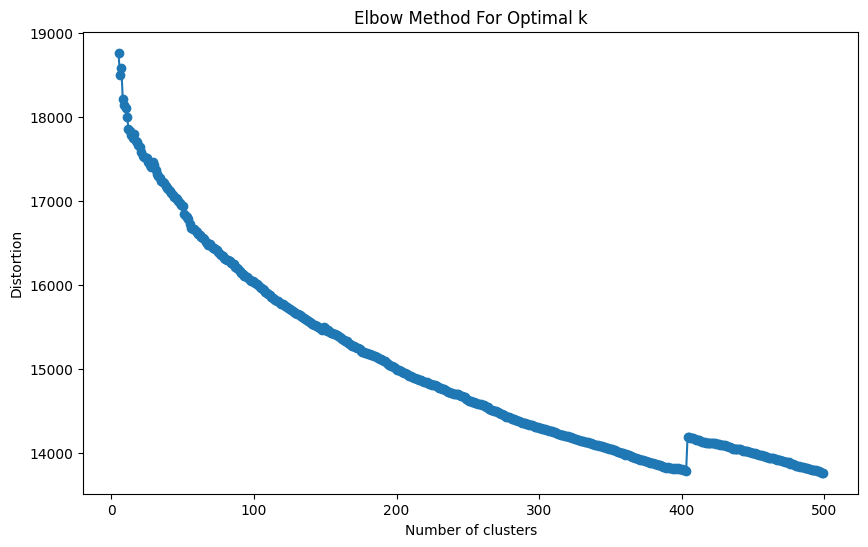

In [72]:
# affichage du graphique de l'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, distortions, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

Il y a une rupture à 400 mais la courbe continue ed décroitre, difficile de retenir un cluster

Meilleur k : 495 (silhouette = 0.1219)


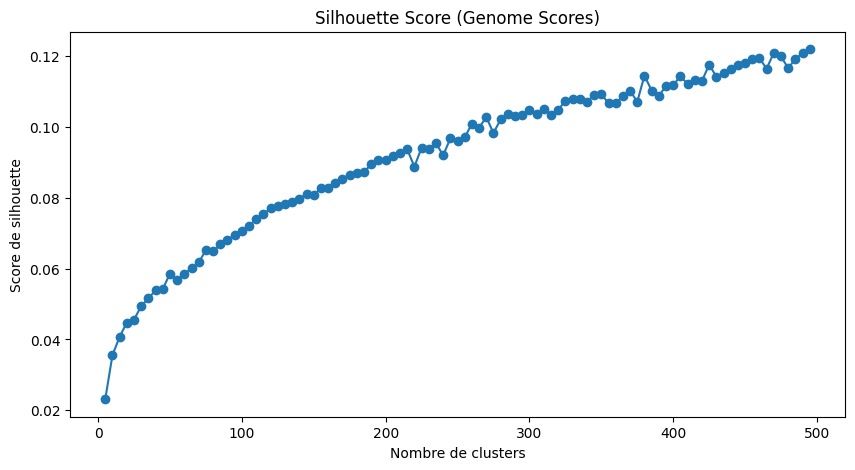

In [73]:
# méthode de la silhouette pour trouver le k optimal
silhouette_scores = []
range_n_clusters = range(5, 500, 5)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix_cl)
    silhouette_scores.append(silhouette_score(tfidf_matrix_cl, labels))

best_k = list(range_n_clusters)[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k : {best_k} (silhouette = {max(silhouette_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Silhouette Score (Genome Scores)')
plt.show()

le meilleur k est à 495, soit la dernière valeur, et un score relativement faible. A priori il y a plus de 495 clusters. 

In [ ]:
# nous allons partir sur 495 clusters
kmeans = KMeans(n_clusters=495, random_state=42)
kmeans.fit(tfidf_matrix_cl)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",495
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [77]:
def recommander_films_cluster(movie_id, num_recommendations=10):
    idx = indices[movie_id]
    #titre_film = titre_vers_id[titre_vers_id == movie_id].index[0]
    titre_film = tagsMovie.iloc[idx]['title']
    print(f"Films recommandés pour : {titre_film} (movieId={movie_id})\n")

    cluster_label = kmeans.labels_[idx]
    indices_cluster = np.where(kmeans.labels_ == cluster_label)[0]
    indices_cluster = indices_cluster[indices_cluster != idx]
    top_indices = indices_cluster[:num_recommendations]

    res = [(tagsMovie.iloc[i]['title'], kmeans.labels_[i]) for i in top_indices]

    return tabulate(res, headers=["Titre", "Cluster"], tablefmt="pretty")

# Affichage des recommandations
print(recommander_films_cluster(movie_id))

Films recommandés pour : Matrix, The (1999) (movieId=2571)

+----------------------------------+---------+
|              Titre               | Cluster |
+----------------------------------+---------+
|       Strange Days (1995)        |   329   |
|    Lawnmower Man, The (1992)     |   329   |
|       Sliding Doors (1998)       |   329   |
|           Tron (1982)            |   329   |
|   What Dreams May Come (1998)    |   329   |
|         eXistenZ (1999)          |   329   |
|   Thirteenth Floor, The (1999)   |   329   |
| Run Lola Run (Lola rennt) (1998) |   329   |
|        Me Myself I (2000)        |   329   |
|        Flatliners (1990)         |   329   |
+----------------------------------+---------+


Les recommandations ne semblent pas pertinentes, ce qui confirme la nécessité d'augmenter le nombre de clusters

************  
**Modèle 4** : cluster sur la base des genome tags  
************  

In [79]:
# créons un dataframe qui contient les genome tags, en mettant movieId comme index
mv_genome = genomeMovie.set_index('movieId')
mv_genome = mv_genome[['tag']]

display(mv_genome.head())
tfidf_cl_genome = TfidfVectorizer()
tfidf_matrix_cl_genome = tfidf_cl_genome.fit_transform(mv_genome['tag'])


,tag
movieId,
1,3d action adventure affectionate animal movie ...
2,action adapted from:book adventure animal movi...
3,chase comedy crappy sequel destiny family fish...
4,adultery betrayal chick flick divorce feel goo...
5,catastrophe chase comedy crappy sequel culture...


In [80]:
# recherche du k optimal pour le clustering KMeans
range_n_clusters_gn = range(5, 500, 5)
distortions_gn = []
for n_clusters in range_n_clusters_gn:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tfidf_matrix_cl_genome)
    distortions_gn.append(kmeans.inertia_)  # inertia_ fonctionne sur les matrices sparse
    print(f"Distortion for {n_clusters} clusters: {distortions_gn[-1]:.4f}")

Distortion for 5 clusters: 8619.2453
Distortion for 10 clusters: 8122.6434
Distortion for 15 clusters: 7734.7712
Distortion for 20 clusters: 7498.2130
Distortion for 25 clusters: 7362.8516
Distortion for 30 clusters: 7256.9396
Distortion for 35 clusters: 7168.2988
Distortion for 40 clusters: 7072.4193
Distortion for 45 clusters: 7015.6496
Distortion for 50 clusters: 6950.8867
Distortion for 55 clusters: 6908.4242
Distortion for 60 clusters: 6857.6638
Distortion for 65 clusters: 6810.4929
Distortion for 70 clusters: 6762.3808
Distortion for 75 clusters: 6707.7878
Distortion for 80 clusters: 6674.1673
Distortion for 85 clusters: 6632.7274
Distortion for 90 clusters: 6604.9719
Distortion for 95 clusters: 6579.7728
Distortion for 100 clusters: 6546.4882
Distortion for 105 clusters: 6527.0687
Distortion for 110 clusters: 6498.6121
Distortion for 115 clusters: 6473.9908
Distortion for 120 clusters: 6460.5961
Distortion for 125 clusters: 6432.1868
Distortion for 130 clusters: 6418.0681
Distor

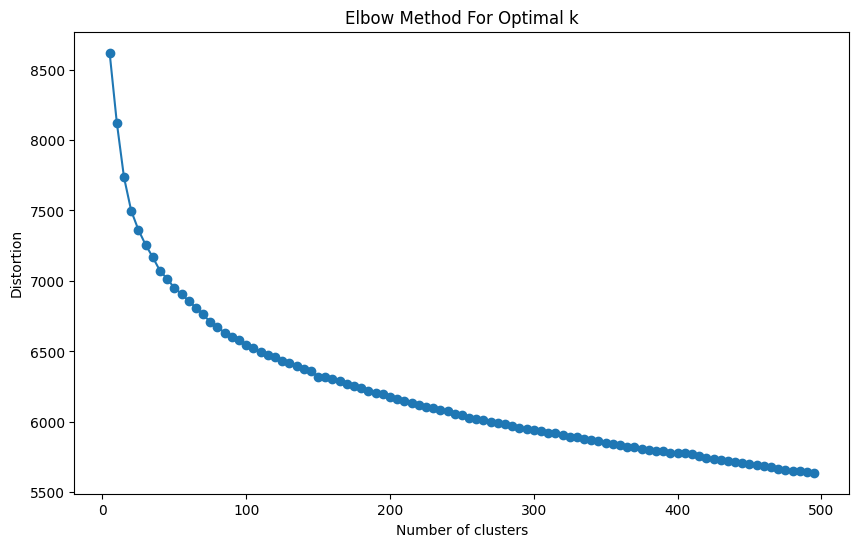

In [81]:
# affichage du graphique de l'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters_gn, distortions_gn, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

Meilleur k : 20 (silhouette = 0.0526)


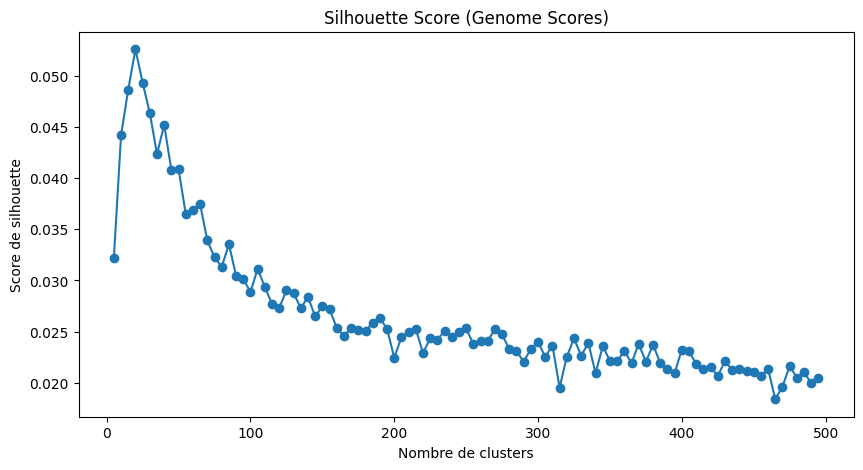

In [82]:
# méthode de la silhouette pour trouver le k optimal
silhouette_scores = []

for k in range_n_clusters_gn:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix_cl_genome)
    silhouette_scores.append(silhouette_score(tfidf_matrix_cl_genome, labels))

best_k = list(range_n_clusters_gn)[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k : {best_k} (silhouette = {max(silhouette_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters_gn, silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Silhouette Score (Genome Scores)')
plt.show()

le k optimal est 20, ce qui est assez faible. La méthode KMeans ne semble pas adaptée  

In [83]:
kmeans_gn = KMeans(n_clusters=20, random_state=42)
kmeans_gn.fit(tfidf_matrix_cl_genome)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",20
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [85]:
def recommander_films_cluster_gn(movie_id, num_recommendations=50):
    idx = indices_genome[movie_id]
    #titre_film = titre_vers_id[titre_vers_id == movie_id].index[0]
    titre_film = genomeMovie.iloc[idx]['title']
    print(f"Films recommandés pour : {titre_film} (movieId={movie_id})\n")

    cluster_label = kmeans_gn.labels_[idx]
    indices_cluster = np.where(kmeans_gn.labels_ == cluster_label)[0]
    indices_cluster = indices_cluster[indices_cluster != idx]
    top_indices = indices_cluster[:num_recommendations]

    res = [(genomeMovie.iloc[i]['title'], kmeans_gn.labels_[i]) for i in top_indices]

    return tabulate(res, headers=["Titre", "Cluster"], tablefmt="pretty")

# Affichage des recommandations
#movie_id = rechercher_par_titre(exple_titre)
print(recommander_films_cluster_gn(movie_id))

Films recommandés pour : Matrix, The (1999) (movieId=2571)

+-----------------------------------------------------------+---------+
|                           Titre                           | Cluster |
+-----------------------------------------------------------+---------+
|         Twelve Monkeys (a.k.a. 12 Monkeys) (1995)         |   13    |
|                     Screamers (1995)                      |   13    |
|                  Johnny Mnemonic (1995)                   |   13    |
|                      Species (1995)                       |   13    |
|                     Waterworld (1995)                     |   13    |
|         Star Wars: Episode IV - A New Hope (1977)         |   13    |
|                 Nemesis 2: Nebula (1995)                  |   13    |
|                      Stargate (1994)                      |   13    |
|               Star Trek: Generations (1994)               |   13    |
|               Village of the Damned (1995)                |   13    |
|   